<a href="https://colab.research.google.com/github/nickplas/Intro_to_ML_25-26/blob/main/notebooks/Lab-3.Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning: Linear and Logistic Regression

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
np.random.seed(404)

## Data Geneation (see Lab 1)

Linear model $y=wx+\varepsilon$, with $\varepsilon \sim \mathcal{N}(0,\sigma)$

In [38]:
def datagen(d, points, m, M, w, sigma):
    """
    Parameters
    ----------
    d : int
        Dimension of each data sample
    points : int
        Number of points to be generated
    m : float
        Lower bound for the domain of the data points
    M : float
        Upper bound for the domain of the data points
    w : float array of dim d
        Vector of weights of the linear model
    sigma : float
        Standard deviation of the noise eps
    """
    X = np.zeros((points, d))
    for i in range(points):
        X[i,:] = np.random.uniform(m, M, d)
    eps = np.random.normal(0, sigma, points)
    y = np.dot(X, w) + eps
    return X, y

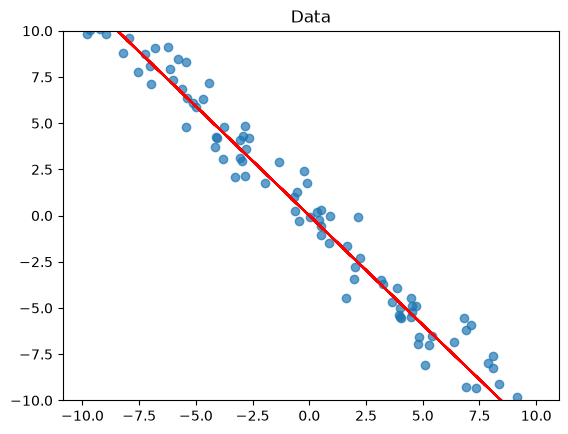

In [39]:
# usage example
d = 1
w = np.random.normal(0, 1, d)
sigma = 1
points = 100
m = -10
M = 10

X_reg, y_reg = datagen(d, points, m, M, w, sigma)

# plotting the generated dataset
plt.scatter(X_reg, y_reg, alpha = 0.7)
plt.plot(X_reg, np.dot(X_reg, w), '--', c='r')
plt.title('Data')
plt.ylim([m, M])

plt.show()

## Linear Regression

Given a dataset $\mathcal{D}=\{(x_i, y_i)\}_{i=1}^n ⊆ \mathbb{R}^d \times \mathbb{R}$ we want to compute the best fitting line, i.e. the parameters $w$ of the line $y=X\cdot w$.

### Analytic Solution

* **Ordinary Linear Regression (i.e. no regularization):**

$$
y=Xw,\;\;\;\; w=X^{-1}y,\;\;\;\;X^{-1}=(X^{T}X)^{-1}X^{T}
$$

$$
w=(X^{T}X)^{-1}X^{T}y
$$

**Recall**: we cannot invert a matrix which is not squared, so we need to resort to the Moore-Penrose pseudo-inverse, i.e. $X^{-1}\approx (X^TX)^{-1}X^T$


Interesting blog post (with some spoilers) showing this analytic derivation and its implementation: https://knork.medium.com/linear-regression-in-python-from-scratch-with-kernels-e9c37f7975b9

In [ ]:
def CloseRegression(X, y):
    """
    Parameters
    ----------
    X : array of float dim n x d
        Matrix containing the dataset
    y : array of float of dim n
        Vector containing the ground truth value of each data point
    """
    #TODO
    
    return w


In [42]:
# Let's try it on the generated dataset
wclose = CloseRegression(X_reg, y_reg)

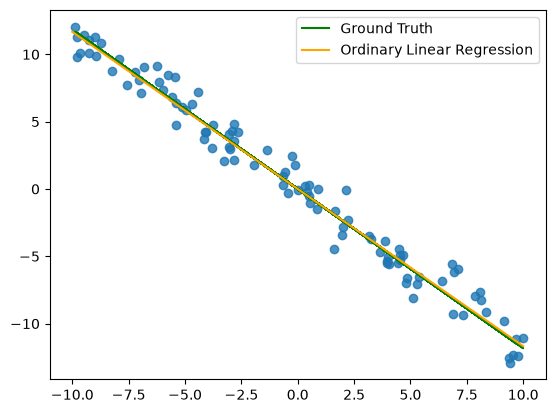

Ground Truth Weights:  [-1.18269089]
Ordinary Linear Regression Weights:  [-1.16734993]


In [43]:
# Create a linearly spaced range of values for x
xlin = np.linspace(-10,10,100)

# Calculate predicted y values for the non-regularized model
ypred = wclose*xlin

plt.plot(X_reg, y_reg, 'o', alpha = 0.8)
plt.plot(X_reg, np.dot(X_reg,w), label='Ground Truth', color='green')
plt.plot(xlin, ypred, label='Ordinary Linear Regression', color='orange')
plt.legend()
plt.show()

print("Ground Truth Weights: ", w)
print("Ordinary Linear Regression Weights: ", wclose)

## Some notes on Bias and Variance

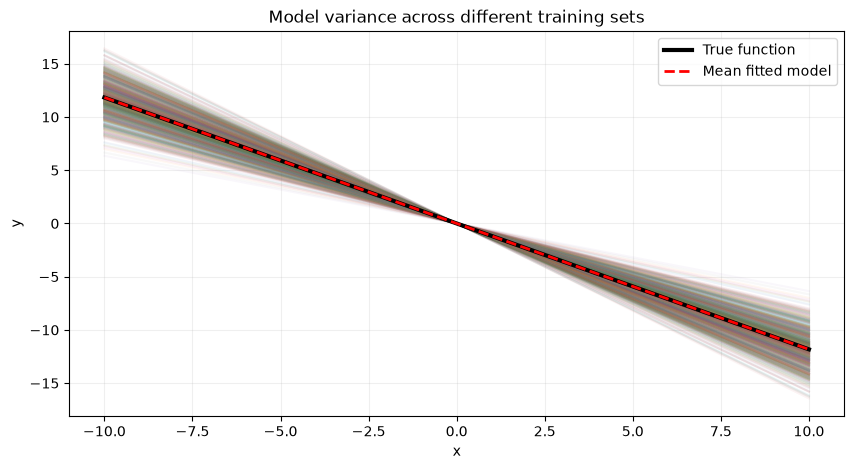

In [44]:
# Model variance: fit the same model on many different training sets
ws = []
plt.figure(figsize=(10, 5))

for i in range(1000):
    X_reg, y_reg = datagen(d, points, m, M, w, 10)
    wclose = CloseRegression(X_reg, y_reg)
    ws.append(wclose[0])

    plt.plot(xlin, wclose[0] * xlin, alpha=0.05)

# True function
plt.plot(xlin, w[0] * xlin, 'k', linewidth=3, label='True function')

# Mean fitted model
w_mean = np.mean(ws)
plt.plot(xlin, w_mean * xlin, 'r--', linewidth=2, label='Mean fitted model')

plt.title('Model variance across different training sets')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

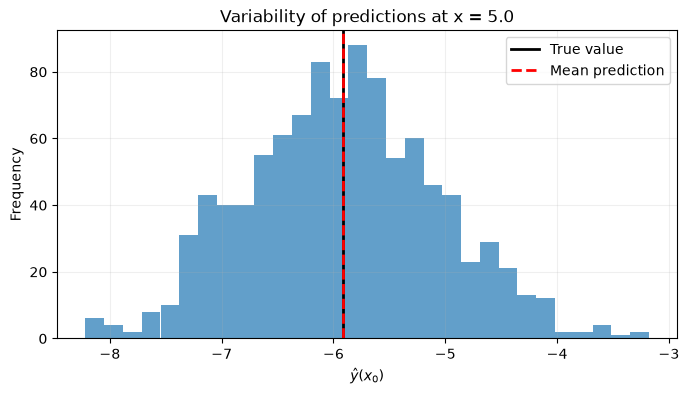

In [48]:
# Variability of the prediction for a fixed x
x0 = 5.0

ypreds = np.array(ws) * x0

plt.figure(figsize=(8, 4))
plt.hist(ypreds, bins=30, alpha=0.7)

# True value
y_true = w[0] * x0
plt.axvline(y_true, color='black', linewidth=2, label='True value')

# Mean prediction
plt.axvline(np.mean(ypreds), color='red', linestyle='--',
            linewidth=2, label='Mean prediction')

plt.xlabel(r'$\hat{y}(x_0)$')
plt.ylabel('Frequency')
plt.title(f'Variability of predictions at x = {x0}')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

/tmp/ipykernel_81934/1590599742.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_81934/1590599742.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_81934/1590599742.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_81934/1590599742.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_81934/1590599742.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_81934/1590599742.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_81934/1590599742.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high =

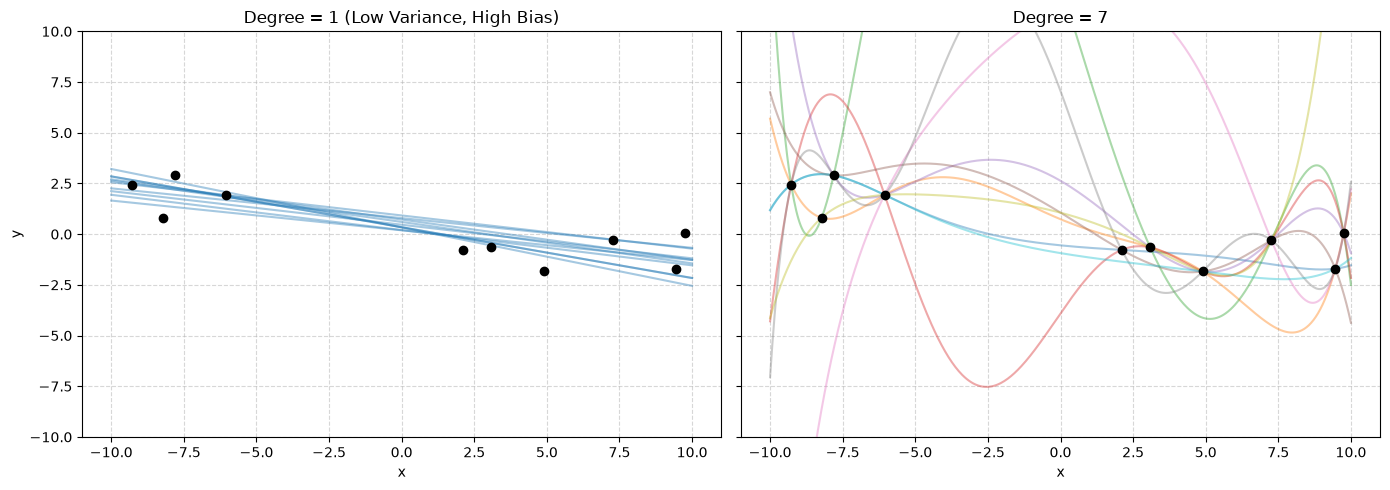

In [49]:
n_points = 10
n_models = 10 
bootstrap_size = 8

# Degree of the more complex model
deg_high = 7

# Generate the data
d = 1
w = np.random.normal(0, 1, d)
sigma = 1
points = 100
m = -10
M = 10
x_train, y_train = datagen(d, n_points, m, M, w, sigma)

x_eval = np.linspace(m, M, 512)

ys_linear = []
ys_high_deg = []

for _ in range(n_models):
    # Bootstrap
    boot_idx = np.random.choice(n_points, size=bootstrap_size, replace=True)
    x_curr = x_train[boot_idx]
    y_curr = y_train[boot_idx]

    # Fit a 1-degree polynomial
    model_lin = np.polyfit(x_curr.squeeze(-1), y_curr, 1)
    ys_linear.append(np.polyval(model_lin, x_eval))

    # Fit a higher-degree polynomial
    model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
    ys_high_deg.append(np.polyval(model_high, x_eval))


# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.scatter(x_train, y_train, color="black", zorder=5)
for y in ys_linear:
    ax1.plot(x_eval, y, color="tab:blue", alpha=0.4)
ax1.set_title("Degree = 1 (Low Variance, High Bias)")

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_ylim(m, M)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.scatter(x_train, y_train, color="black", zorder=5)
for y in ys_high_deg:
    ax2.plot(x_eval, y, alpha=0.4)
ax2.set_title(f"Degree = {deg_high}")
ax2.set_xlabel("x")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

---

## Gradient Descent (GD) method

**Recall**: the gradient indicates the direction of maximal ascent of a function. Hence to find the minimum of a function we have to follow the direction of the negative gradient. In GD we take a step of size $\gamma$ (learning rate). Given a loss function $\mathcal{L}(w)$ it works as:

1. Initialize $w_0$
2. while (condition):
   * compute gradient of the loss at t $\nabla_w \mathcal{L}|_t$
   * update weights as $w_{t+1} = w_t - \gamma \nabla_w \mathcal{L}|_t $


In the case of linear regression the squared error loss and its gradient read as:


$$
\mathcal{L}=\frac{1}{n}\|y-Xw\|_{2}^{2},\;\;\;\;\nabla_{w} \mathcal{L} = -\frac{2}{n}X^T(y-Xw)
$$

As condition for the while loop we use a predefined number of iterations.

In summary, Gradient Descent is an iterative optimization technique that adjusts a parameter vector to minimize a loss function. It does this by taking steps in the direction of the negative gradient, gradually converging towards the minimum of the function. For linear regression, this means finding the best-fit line that minimizes the squared error between predictions and actual values.


In [ ]:
def SquareLoss(X, y, w):
    """
    Parameters
    ----------
    X : array of float dim n x d
        Matrix containing the dataset
    y : array of float of dim n
        Vector containing the ground truth value of each data point
    w : array of float of dim d
        Weights of the fitted line
    """
    return np.linalg.norm(y - X@w, 2)

The function calculates the square loss as follows:

1. `X @ w`: This is the matrix-vector multiplication of the dataset `X` with the weight vector `w`. It results in a vector of predicted values, one for each data point.

2. `y - X @ w`: This computes the element-wise difference between the true values `y` and the predicted values obtained in the previous step.

3. `LA.norm(y - X @ w, 2)`: This computes the L2 norm (Euclidean norm) of the vector obtained in step 2, which is essentially the square root of the sum of squared differences between true and predicted values.

4. The computed L2 norm represents the square loss, which measures how well the linear model's predictions match the actual ground truth values. Smaller values indicate better model fit, while larger values indicate greater prediction errors.

In [ ]:
def GD(X, y, iters, gamma, points, d, tol = 1e-3):
    """
    Parameters
    ----------
    X : array of float dim n x d
        Matrix containing the dataset
    y : array of float of dim n
        Vector containing the ground truth value of each data point
    iters : int
        Number of GD iterations
    gamma : float
        Learning rate
    points : int
        Number of points in our dataset
    d : int
        Dimensionality of each data point in the dataset
    """
    # Initialize arrays to store weights and losses
    W = np.zeros((iters,d)) # To store weights at each iteration
    L = np.zeros(iters) # To store losses at each iteration

    # Initialize the weight vector w with small random values
    w = np.random.normal(0, 0.1, d)
    n = X.shape[0]

    # GD iterations
    W[0] = w
    L[0] = SquareLoss(X, y, w)/n
    for i in range(iters):
        #TODO: implement the gradient descent update rule
        w = ...
        W[i] = w
        
        # Implement the loss calculation and check for convergence
        loss = ...
        L[i] = loss

        if loss < tol:
            ...
    return i, W, L

In [69]:
# Determine the dimensionality of the dataset
d = np.shape(X_reg)[1]

iters = 1000
n_points = 100
gamma = 0.001

# Apply Gradient Descent (GD) to train a linear regression model
i, wgd, L = GD(X_reg, y_reg, iters, gamma, points, d)
# the last stored weights are the most updated ones
wpred = wgd[i,:].T

In [72]:
w, wpred, np.abs(w-wpred)

(array([-0.12523222]), array([-1.14475862]), array([1.0195264]))

Text(0.5, 1.0, 'Squared Loss')

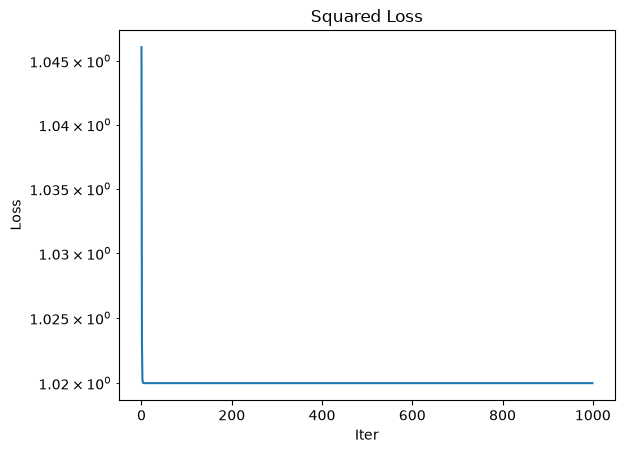

In [68]:
plt.plot(L)
plt.xlabel('Iter')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Squared Loss')

## Logistic Regression

### Generate the data and plot (noisy) data (see Lab 1)

In [73]:
def mixGauss(means, sigmas, n):
    """
    Parameters
    ----------
    means : matrix/list of float of dim n_classes x dim_data (d)
        Means of the Gaussian functions
    sigmas : array/list of float of dim n_classes
        Standard deviation of the Gaussian functions
    n : int
        Number of points for each class
    """
    means = np.array(means)
    sigmas = np.array(sigmas)

    d = np.shape(means)[1] # the means matrix is of n_classes x dim_data
    num_classes = sigmas.size # the number of variances is the number of classes

    data = np.full((n * num_classes, d), np.inf)
    labels = np.zeros(n * num_classes)

    # iterate over classes
    for idx, sigma in enumerate(sigmas):
        # generates n points around means[idx] with cov sigma[idx]
        data[idx * n:(idx + 1) * n] = np.random.multivariate_normal(
            mean=means[idx], cov=np.eye(d) * sigmas[idx] ** 2, size=n)
        labels[idx * n:(idx + 1) * n] = idx

    if(num_classes == 2):
        labels[labels == 0] = -1

    return data, labels

def labelsnoise(perc, labels):
    """
    Parameters
    ----------
    perc : float
        Percentage of labels to be flipped
    labels: array of int of dim n_classes
        Array containing labels idxs
    """
    points = np.shape(labels)[0]
    noisylabels = np.copy(np.squeeze(labels))
    n_flips = int(np.floor(points * perc / 100)) # floor: nearest integer by defect
    idx_to_flip = np.random.choice(points, size=n_flips, replace=False) # replace is false since the same index cannot be chosen twice
    noisylabels[idx_to_flip] = -noisylabels[idx_to_flip] # for binary this turns -1 into 1 and viceversa
    return noisylabels

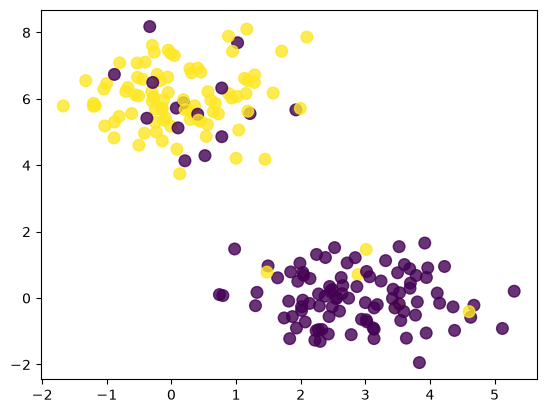

In [74]:
# usage example
means = [[3,0],[0,6]]
sigmas = [0.9,0.9]
n = 100

X, labels = mixGauss(means, sigmas, n)
labels = labelsnoise(10, labels) # 10% of the labels are flipped

# plotting the generated dataset
plt.scatter(X[:,0], X[:,1], s=70, c=labels, alpha=0.8)
plt.show()

***Sigmoidal function***

$$
\sigma(wx_i) = \frac{1}{1 + e^{-wx_i}}
$$


The sigmoidal function, often denoted as σ or the sigmoid function, is a mathematical function commonly used in machine learning and statistics. It maps any real number 'wx_i' to a value between 0 and 1.

- **'wx_i'**: This is the input to the sigmoid function. It's a real number obtained by taking the dot product of a weight 'w' and a feature 'x_i'. 'w' represents a weight parameter, and 'x_i' represents a input variable.

- **'$1 + e^{-wx_i}$'**: Here, '1' is added to the result obtained in the previous step. This addition ensures that the denominator is never zero.

- **'$\frac{1}{1 + e^{-wx_i}}$'**: Finally, the function takes the reciprocal of the result from the previous step, which ensures that the output of the sigmoid function is in the range (0, 1).

In summary, the sigmoidal function takes an input 'wx_i,' applies a mathematical transformation involving exponentiation and division, and produces an output in the range between 0 and 1. It's often used in machine learning for tasks like binary classification, where it maps input values to probabilities. When 'wx_i' is positive, the sigmoid function approaches 1, and when 'wx_i' is negative, it approaches 0, making it useful for modeling probabilities or decision boundaries.

In [ ]:
def sigmoid(x, w):
    """
    Parameters
    ----------
    x : array of dim n
        Array containing the datapoint
    w : float
        Number representing the 'temperature' of the sigmoid
    """
    #TODO
    return y

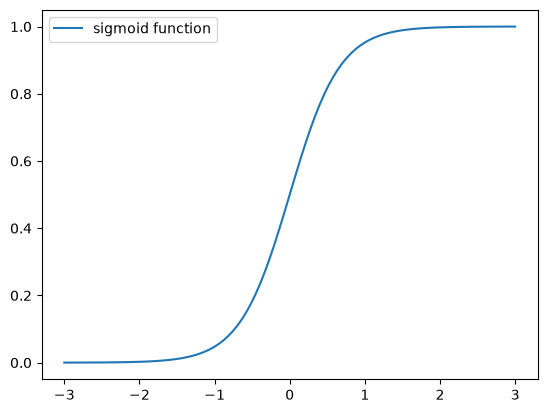

In [79]:
# usage example
x = np.linspace(-3,3,100)
w = 3
y = sigmoid(x, w)

plt.plot(x, y, label='sigmoid function')
plt.legend()
plt.show()

## Logistic Loss

In logistic regression, the goal is to model the probability that a given input 'x' belongs to a particular class (usually 0 or 1). To do this, logistic regression employs a hypothesis function 'h(x)' that transforms the linear combination of features and weights 'w^T*x' into a probability value using the sigmoid function 'σ(wx)'.

* For regression the hypothesis was: $h(x)=w^Tx$
* For logistic regression is $h(x)=\sigma(w,x)=\frac{1}{1+e^{-w^Tx}}$

- **Decision Boundary**: Logistic regression makes binary classification decisions based on the value of 'h(x)':

$$
h(x) =
\begin{cases}
  >0.5, & w^{T}x>0\\
  <0.5, & w^{T}x<0
\end{cases}
$$

  If 'h(x)' is greater than 0.5, the model predicts class 1; otherwise, it predicts class 0. The threshold of 0.5 is commonly used, but it can be adjusted depending on the problem.

**Logistic loss Formula**


The logistic loss is a measure used to assess the goodness of fit of a logistic regression model. It quantifies the difference between the model's predictions (given by 'h(x,w)') and the actual binary labels 'y'. Here's the formula for the logistic loss:

$$
L=-y\cdot \log(h(x,w))-(1 - y)\cdot \log(1-h(x,w))
$$

  - 'y' represents the actual binary label (0 or 1).
  - 'h(x,w)' is the predicted probability that 'x' belongs to class 1 based on the logistic regression model with weights 'w'.

The logistic loss measures how well the model's predicted probabilities align with the true binary labels. When the true label 'y' is 1, the first term measures the loss associated with the model predicting class 0 when it should be 1. Similarly, when 'y' is 0, the second term measures the loss associated with the model predicting class 1 when it should be 0.

**Minimization of the Logistic loss**

To train a logistic regression model, you need to find the optimal set of weights 'w' that minimizes the logistic loss. This is typically done using an optimization algorithm like gradient descent. Here's the update rule for minimizing the logistic loss with gradient descent:

$$
w_{j}\leftarrow w_{j}-\frac{\gamma}{n}\sum_{i=1}^{n}(h(x^{i})-y^{i})x^{i}_{j}
$$
In compact form:

$$
w\leftarrow w -\frac{\gamma}{n}X^{T}(h(X)-y)
$$

The update rule essentially adjusts each weight 'w_j' based on the difference between the model's prediction and the actual label for each data point. The goal is to iteratively update the weights to minimize the logistic loss, ultimately leading to a well-fitted logistic regression model for binary classification.



In [83]:
# this is a batched version to get logistic output for the whole matrix at the same time
def sigmoidM(X, w):
    """
    Parameters
    ----------
    X : array of dim n x d
        Matrix containing the dataset
    w : array of dim d
        Vector representing the coefficients of the logistic model
    """
    y = 1/(1 + np.exp(-np.matmul(X,w)))
    return y

- `np.matmul(X, w)` computes the dot product of the feature matrix `X` and the coefficient vector `w` for each data point. This essentially calculates the linear part of the logistic regression model.

- `np.exp(-np.matmul(X, w))` computes the exponential of the negative linear combination.

- `1 / (1 + np.exp(-np.matmul(X, w)))` applies the sigmoid transformation to each element of the linear combination, resulting in a vector of probabilities. These probabilities represent the likelihood of each data point belonging to the positive class in binary classification.

In [84]:
def LogisticLoss(X, y, w):
    """
    Parameters
    ----------
    X : array of dim n x d
        Matrix containing the dataset
    y : array of dim n
        Vector representing the ground truth label of each data point
    w : array of dim d
        Vector representing the coefficients of the logistic model
    """
    cost = -y * (np.log(sigmoidM(X,w))) - (1 - y) * np.log(1 - sigmoidM(X,w))
    return cost

  - `labels * log(sigmoid(Xw))` computes the log-likelihood of the true class (1) for each data point when the model predicts the probability using `sigmoidM(X, w)`. This part measures how well the model predicts positive examples when the true label is 1.

  - `(1 - labels) * log(1 - sigmoid(Xw))` computes the log-likelihood of the true class (0) for each data point when the model predicts the probability. This part measures how well the model predicts negative examples when the true label is 0.

  - The sum over all data points and the negative scaling factor `(1/n)` compute the average logistic loss over the entire dataset.

This code calculates the logistic loss, which quantifies how well a logistic regression model's predictions match the true labels in a binary classification problem.

In [ ]:
def GDLogistic(X, labels, iters, gamma):
    """
    Parameters
    ----------
    X : array of dim n x d
        Matrix containing the dataset
    labels : array of dim n
        Vector representing the ground truth label of each data point
    iter : int
        Number of GD iterations
    gamma : float
        Learning rate
    """
    d = np.shape(X)  # d contains the shape of X, which is a tuple (n, d)
    loss = np.zeros(iters)  # Create an array to store the cost at each iteration
    w = np.random.uniform(0, 0.01, d[1])  # Initialize w with random values
    W = np.zeros((iters, 2))  # Create an array to store the weight vectors at each iteration
    n = X.shape[0]

    for i in range(iters):
        #TODO
        W[i] = w
        loss_vector = ...
        loss[i] = ...
        w = ...
        
    return W, loss


In [91]:
# usage example
iters = 500
gamma = 0.0001
W, cost = GDLogistic(X, labels, iters, gamma)

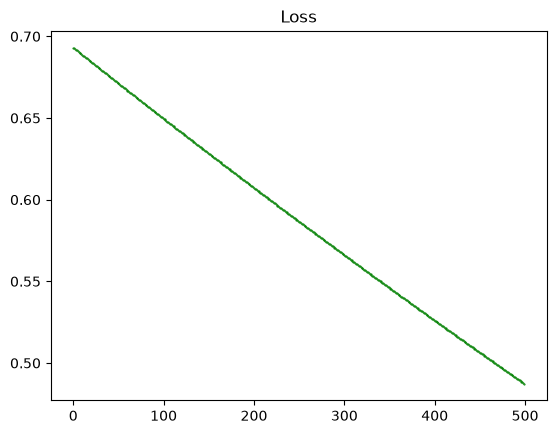

In [92]:
plt.plot(cost, 'go', markersize=0.5)
plt.title('Loss')
plt.show()

***Plotting the decision boundary***

The decision boundary is used to predict which class a new point might correspond to.
The decision boundary in a classification problem is a mathematical construct that separates different classes or categories in the feature space.

Its derivation is:

$$0=w^{T}x=x_{1}w_{1}+x_{2}w_{2}\rightarrow x_{2}=-\frac{x_{1}w_{1}}{w_{2}}$$

In practical terms, when you have trained a logistic regression or linear classification model, the decision boundary is the line (in 2D) or hyperplane (in higher dimensions) that separates the two classes. New data points are classified based on which side of the decision boundary they fall on. If they are on one side, they are assigned to class 0, and if they are on the other side, they are assigned to class 1. The equation provided helps calculate the position of this boundary in terms of the feature values and the model's weights.


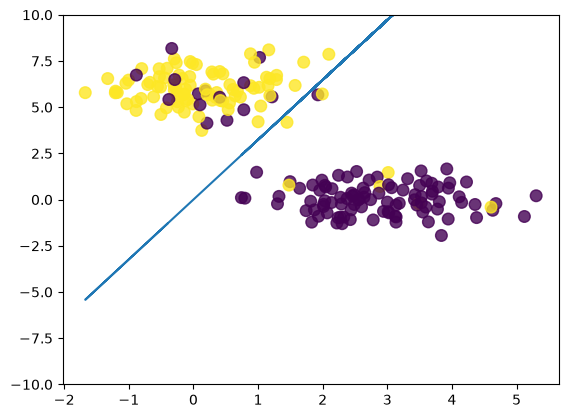

In [89]:
w = W[iters-1, :]
y = -(np.dot(X[:,0], w[0])/w[1])

plt.scatter(X[:,0], X[:,1], s=70, c=labels, alpha=0.8)
plt.plot(X[:,0], y)
plt.ylim([m, M])
plt.show()

## Accuracy

The accuracy is a metric used for classification problems defined as the number of correct predictions divided by the total number of predictions.

In [ ]:
def accuracy(X, w, labels):
    """
    Parameters
    ----------
    X : array of dim n x d
        Matrix containing the dataset
    w : array of dim d
        Vector representing the coefficients of the logistic model
    labels : array of dim n
        Vector representing the ground truth label of each data point
    """
    a = labels - (2*np.round(sigmoidM(X,w))-1)
    acc = np.sum(a==0)/np.shape(X)[0]
    return acc

 For variable `a`
  - `np.round(sigmoidM(X,w))`: It computes the sigmoid function's output for each data point in the dataset.
  - `2*np.round(sigmoidM(X,w))-1`: This line scales the sigmoid outputs so that they are either 1 or -1.
  - `labels - (2*np.round(sigmoidM(X,w))-1)`: This subtracts the ground truth labels from the scaled sigmoid outputs. This results in an array where a value of 0 indicates a correct prediction, and non-zero values indicate incorrect predictions.

For variable `acc`

- This line calculates the accuracy by counting the number of correct predictions (where `a` is equal to 0) and dividing it by the total number of data points (`np.shape(X)[0]`), which gives the proportion of correctly classified data points.

In [ ]:
accuracy(X, w, labels)

---

4. Explore the `scikit-learn` functions for linear and logistic regression.

In [ ]:
#%pip install scikit-learn

* Linear Regression: [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [ ]:
from sklearn.linear_model import LinearRegression
#TODO

* Logistic Regression: [LogisticRregression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [ ]:
from sklearn.linear_model import LogisticRegression
#TODO

---

## Exam-like questions

- What does "linear" means in Linear regression?
- What does the variance represent in the context of a regression model?
- Do an example of non-linear model (other than logistic)
- What does the decision boundary in log. regression represent?
- What is the link between cross entropy and Maximum likelihood estimation (MLE)?